**Zomato Data Analysis Project**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Zomato data .csv')
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [5]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

df['rate']=df['rate'].apply(handleRate)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB


**Q1. What type of restaurant do the majority of customers order from?**

In [7]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'type of resturant')

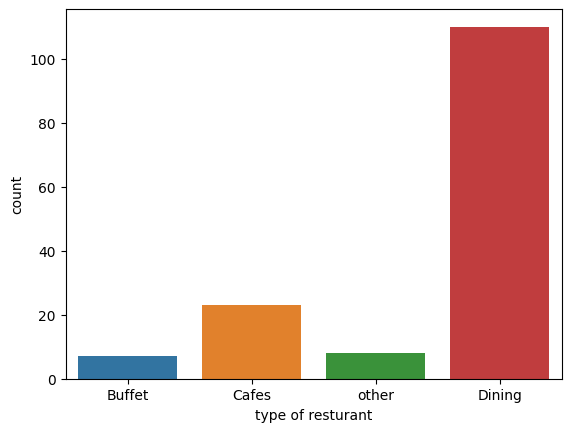

In [8]:
sns.countplot(x=df['listed_in(type)'],hue=df['listed_in(type)'],)
plt.xlabel("type of resturant")

**Conclusion - Majority of the resturant falls in "Dinning Category".**

**Q2. How many votes has each type of restaurant received from customers?**

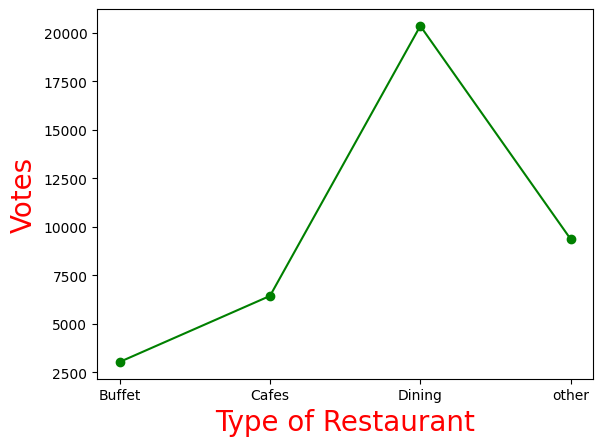

In [9]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
                         
result = pd.DataFrame({'votes':grouped_data})

plt.plot(result, color="green", marker="o")
plt.xlabel("Type of Restaurant", color="red", size=20)
plt.ylabel("Votes", color="red", size=20)

plt.show()

**Conclusion - Dinning Restaurant has Received Maximum Votes**

**Q3. What ratings do the majority of restaurants have?**

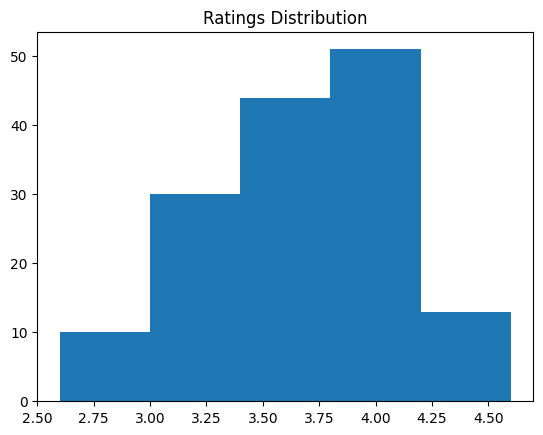

In [10]:
plt.hist(df['rate'], bins=5)

plt.title("Ratings Distribution")
plt.show()

**Counclusion - The Majority Resturant received ratings from 3.5 to 4**

**Q4. What is the average spending of couples on each order?**



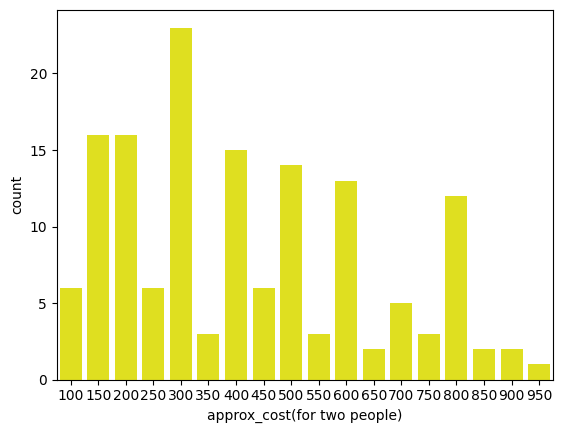

In [23]:
couple_data = df['approx_cost(for two people)']

sns.countplot(x=couple_data,color='Yellow')

plt.show()

**Counclusion - The Majority of Couples prefered resturants with an approximate cost of 300 rupees.**

**Q5. Which mode (online or offline) has received the maximum rating?**

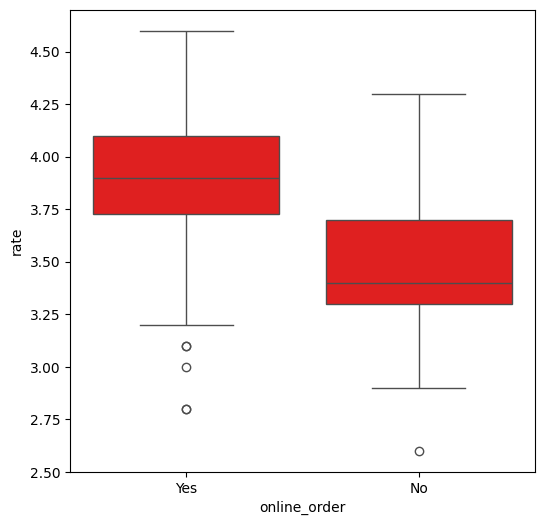

In [30]:
plt.figure(figsize=(6,6))

sns.boxplot(
    x='online_order',color='red',
    y='rate',
    data=df
)

plt.show()

**Counclusion - Offline Order received lower rating in comparison to online order**

**Q6. Which type of restaurant received more offline orders?**

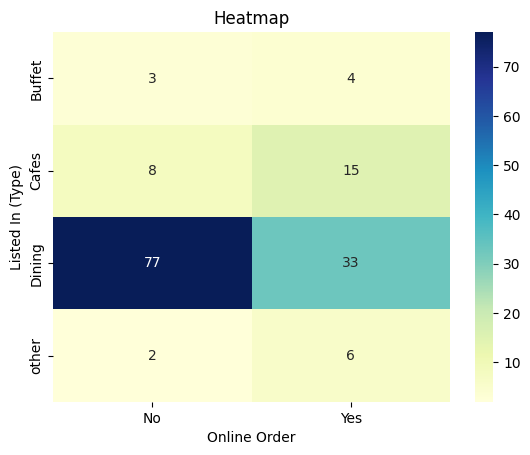

In [37]:
pivot_table = df.pivot_table(
    index='listed_in(type)',
    columns='online_order',
    aggfunc='size',
    fill_value=0
)

sns.heatmap(
    pivot_table,
    annot=True,
    cmap='YlGnBu',
    fmt='d'
)

plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed In (Type)")

plt.show()

**Counclusion - Dinning Resturants primarily accept offline orders, whereas cafes primarily received online orders. This suggests that clients preffered to orders in person at resturants, but prefer online ordering at cafes**